# Phase Recovery v14  
## Time-lens + AI + GS hybrid

This notebook upgrades the time-lens workflow into a **hybrid AI + GS reconstruction**.

## Main idea

v13 showed something important:

- the time-lens measurement adds real diversity
- but GS alone still struggles to recover the spectrum

So v14 changes the inverse method:

```text
dispersion measurement + time-lens measurement
→ AI coarse spectral estimate
→ hybrid GS refinement with mixed physics constraints
```

That is the whole point of v14:
- keep the richer measurement physics from v13
- add a learned initializer / prior
- use GS only as the physics-refinement stage


## Target outcome

This notebook is designed to answer:

> can a time-lens-assisted measurement pair recover dip structure better when the inverse is helped by AI?

We compare:

- dispersion-only GS baseline
- time-lens-only GS baseline
- time-lens + AI + GS hybrid


In [1]:
# ============================================================
# 1. Imports
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8.5, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

GLOBAL_SEED = 7
rng = np.random.default_rng(GLOBAL_SEED)

print("NumPy:", np.__version__)
print("Torch available:", TORCH_AVAILABLE)
if TORCH_AVAILABLE:
    print("Torch:", torch.__version__)


NumPy: 2.3.5
Torch available: True
Torch: 2.10.0+cpu


## Shared physics


In [2]:
# ============================================================
# 2. Constants, grids, and helpers
# ============================================================

GHZ = 1e9
NS = 1e-9
PS = 1e-12

N = 2**14
df = 0.05 * GHZ
f = (np.arange(N) - N // 2) * df
w = 2 * np.pi * f

dt = 1.0 / (N * df)
t = (np.arange(N) - N // 2) * dt

def fftc(x):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))

def ifftc(X):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))

def normalize_peak(x, eps=1e-12):
    peak = np.max(np.abs(x))
    return x / max(peak, eps)

def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def correlation_coefficient(a, b):
    a = np.asarray(a).ravel().astype(float)
    b = np.asarray(b).ravel().astype(float)
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt(np.sum(a**2) * np.sum(b**2)) + 1e-12
    return float(np.sum(a * b) / denom)

def gaussian_kernel_1d(length=101, sigma=12):
    x = np.arange(length) - length // 2
    k = np.exp(-(x**2) / (2 * sigma**2))
    return k / np.sum(k)

def gaussian_smooth(x, sigma=12, length=101):
    k = gaussian_kernel_1d(length=length, sigma=sigma)
    return np.convolve(np.asarray(x, dtype=float), k, mode="same")

print("Frequency span (GHz):", (f[-1] - f[0]) / GHZ)
print("Time span (ns):", (t[-1] - t[0]) / NS)
print("dt (ps):", dt / PS)


Frequency span (GHz): 819.15
Time span (ns): 19.998779296875
dt (ps): 1.220703125


In [3]:
# ============================================================
# 3. Spectrum models
# ============================================================

def gaussian_dip(f, center_hz, width_hz, depth=0.85):
    return 1.0 - depth * np.exp(-((f - center_hz) / width_hz) ** 2)

def make_single_line_spectrum(f):
    return np.clip(gaussian_dip(f, center_hz=40 * GHZ, width_hz=2.2 * GHZ, depth=0.95), 0.0, None)

def make_three_line_spectrum(f):
    S = np.ones_like(f, dtype=float)
    centers = [34 * GHZ, 40 * GHZ, 46 * GHZ]
    widths = [1.8 * GHZ, 1.8 * GHZ, 1.8 * GHZ]
    depths = [0.72, 0.88, 0.72]
    for c, wghz, d in zip(centers, widths, depths):
        S *= gaussian_dip(f, center_hz=c, width_hz=wghz, depth=d)
    return np.clip(S, 0.0, None)

def make_random_three_dip_spectrum(f, rng_local):
    centers = np.sort(rng_local.uniform(28, 52, size=3)) * GHZ
    widths = rng_local.uniform(1.4, 2.6, size=3) * GHZ
    depths = rng_local.uniform(0.55, 0.9, size=3)
    S = np.ones_like(f, dtype=float)
    for c, wghz, d in zip(centers, widths, depths):
        S *= gaussian_dip(f, center_hz=c, width_hz=wghz, depth=d)
    return np.clip(S, 0.0, None)

def make_field_from_psd(S, spectral_phase=None):
    amp = np.sqrt(np.maximum(S, 0.0))
    if spectral_phase is None:
        spectral_phase = np.zeros_like(amp)
    return amp * np.exp(1j * spectral_phase)


In [4]:
# ============================================================
# 4. Dispersion and time-lens operators
# ============================================================

def dispersion_transfer_function(w, phi2=0.0, phi3=0.0):
    phase = 0.5 * phi2 * w**2 + (1.0 / 6.0) * phi3 * w**3
    return np.exp(1j * phase)

def propagate_dispersion(Ef, w, phi2=0.0, phi3=0.0):
    return ifftc(Ef * dispersion_transfer_function(w, phi2=phi2, phi3=phi3))

def time_lens_transfer_function(t, C=0.0):
    return np.exp(1j * 0.5 * C * t**2)

def apply_time_lens(e_t, t, C=0.0):
    return e_t * time_lens_transfer_function(t, C=C)

def intensity(x):
    return np.abs(x) ** 2

def temporal_imaging_measurement(Ef, w, t, phi2_pre=0.0, C=0.0, phi2_post=0.0, phi3_pre=0.0, phi3_post=0.0):
    e1 = propagate_dispersion(Ef, w, phi2=phi2_pre, phi3=phi3_pre)
    e2 = apply_time_lens(e1, t, C=C)
    E2 = fftc(e2)
    e3 = ifftc(E2 * dispersion_transfer_function(w, phi2=phi2_post, phi3=phi3_post))
    I3 = normalize_peak(intensity(e3))
    return {
        "field_after_pre_dispersion": e1,
        "field_after_time_lens": e2,
        "field_after_post_dispersion": e3,
        "intensity": I3,
    }


## Benchmark measurements


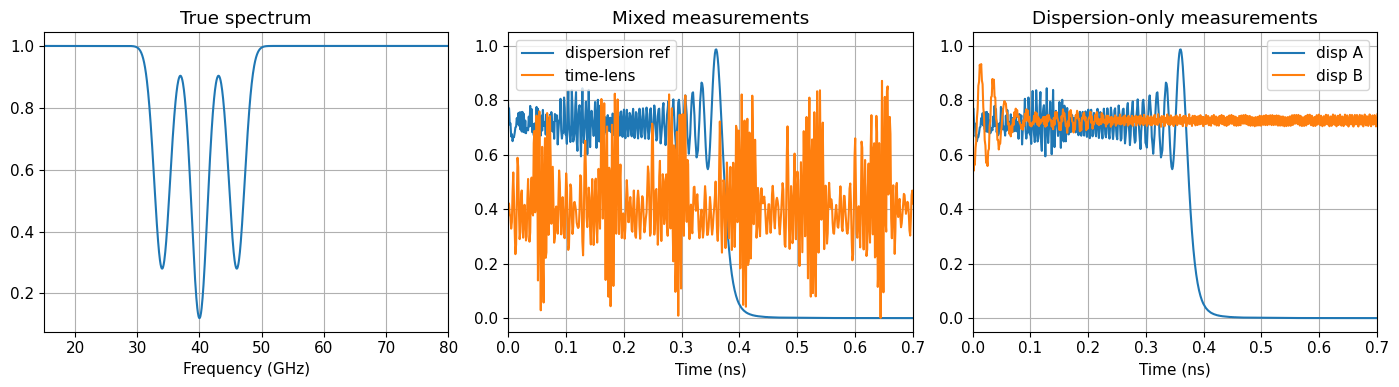

In [5]:
# ============================================================
# 5. Benchmark case
# ============================================================

S_case = make_three_line_spectrum(f)
Ef_case = make_field_from_psd(S_case)

# Dispersion-only pair
phi2_a = 1.5e-22
phi2_b = 6.0e-22

e_a_true = propagate_dispersion(Ef_case, w, phi2=phi2_a)
e_b_true = propagate_dispersion(Ef_case, w, phi2=phi2_b)
I_a = normalize_peak(intensity(e_a_true))
I_b = normalize_peak(intensity(e_b_true))

# Mixed pair: one reference dispersed plane + one time-lens plane
phi2_ref = 1.5e-22
phi2_pre = 1.5e-22
C_lens = 2.0e23
phi2_post = 5.0e-22

e_ref_true = propagate_dispersion(Ef_case, w, phi2=phi2_ref)
I_ref = normalize_peak(intensity(e_ref_true))

sim_lens_true = temporal_imaging_measurement(Ef_case, w, t, phi2_pre=phi2_pre, C=C_lens, phi2_post=phi2_post)
I_lens = sim_lens_true["intensity"]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].plot(f / GHZ, S_case)
axs[0].set_xlim(15, 80)
axs[0].set_title("True spectrum")
axs[0].set_xlabel("Frequency (GHz)")

axs[1].plot(t / NS, I_ref, label="dispersion ref")
axs[1].plot(t / NS, I_lens, label="time-lens")
axs[1].set_xlim(0, 0.7)
axs[1].set_title("Mixed measurements")
axs[1].set_xlabel("Time (ns)")
axs[1].legend()

axs[2].plot(t / NS, I_a, label="disp A")
axs[2].plot(t / NS, I_b, label="disp B")
axs[2].set_xlim(0, 0.7)
axs[2].set_title("Dispersion-only measurements")
axs[2].set_xlabel("Time (ns)")
axs[2].legend()

plt.tight_layout()
plt.show()


## GS baselines


In [6]:
# ============================================================
# 6. Reconstruction helpers
# ============================================================

def gs_two_measurements_general(Ia, Ib, propagate_a_to_b, propagate_b_to_a, n_iter=140, seed=0):
    rng_local = np.random.default_rng(seed)

    maga = np.sqrt(np.maximum(Ia, 0.0))
    magb = np.sqrt(np.maximum(Ib, 0.0))
    phase0 = rng_local.uniform(-np.pi, np.pi, size=maga.shape)
    ea = maga * np.exp(1j * phase0)

    history = {"err_a": [], "err_b": [], "update": []}
    prev = ea.copy()

    for _ in range(n_iter):
        eb_pred = propagate_a_to_b(ea)
        err_b = np.sqrt(np.mean((np.abs(eb_pred) - magb) ** 2))
        eb = magb * np.exp(1j * np.angle(eb_pred))

        ea_pred = propagate_b_to_a(eb)
        err_a = np.sqrt(np.mean((np.abs(ea_pred) - maga) ** 2))
        ea = maga * np.exp(1j * np.angle(ea_pred))

        upd = np.sqrt(np.mean(np.abs(ea - prev) ** 2))
        prev = ea.copy()

        history["err_a"].append(err_a)
        history["err_b"].append(err_b)
        history["update"].append(upd)

    return ea, history

def recover_reference_spectrum_from_time_field(ea, w, phi2_a=0.0, phi3_a=0.0):
    Ea = fftc(ea)
    H_back = np.exp(-1j * (0.5 * phi2_a * w**2 + (1.0 / 6.0) * phi3_a * w**3))
    E0 = Ea * H_back
    return normalize_peak(np.abs(E0) ** 2), E0


In [7]:
# ============================================================
# 7. Baseline A: dispersion-only GS
# ============================================================

def prop_disp_a_to_b(ea):
    Ea = fftc(ea)
    return ifftc(Ea * np.exp(1j * 0.5 * (phi2_b - phi2_a) * w**2))

def prop_disp_b_to_a(eb):
    Eb = fftc(eb)
    return ifftc(Eb * np.exp(1j * 0.5 * (phi2_a - phi2_b) * w**2))

e_rec_disp, hist_disp = gs_two_measurements_general(I_a, I_b, prop_disp_a_to_b, prop_disp_b_to_a, n_iter=140, seed=1)
S_rec_disp, _ = recover_reference_spectrum_from_time_field(e_rec_disp, w, phi2_a=phi2_a)

metrics_disp = {
    "rmse": rmse(normalize_peak(S_case), normalize_peak(S_rec_disp)),
    "corr": correlation_coefficient(normalize_peak(S_case), normalize_peak(S_rec_disp)),
}
metrics_disp


{'rmse': 0.9201119303924356, 'corr': 0.010742460881496866}

In [8]:
# ============================================================
# 8. Baseline B: time-lens GS
# ============================================================

def prop_ref_to_lens(e_ref):
    E_ref = fftc(e_ref)
    E0 = E_ref * np.exp(-1j * 0.5 * phi2_ref * w**2)
    sim = temporal_imaging_measurement(E0, w, t, phi2_pre=phi2_pre, C=C_lens, phi2_post=phi2_post)
    return sim["field_after_post_dispersion"]

def prop_lens_to_ref(e_lens):
    E_lens = fftc(e_lens)
    e_after_lens = ifftc(E_lens * np.exp(-1j * 0.5 * phi2_post * w**2))
    e_before_lens = e_after_lens * np.exp(-1j * 0.5 * C_lens * t**2)
    E0 = fftc(e_before_lens) * np.exp(-1j * 0.5 * phi2_pre * w**2)
    e_ref = ifftc(E0 * np.exp(1j * 0.5 * phi2_ref * w**2))
    return e_ref

e_rec_lens, hist_lens = gs_two_measurements_general(I_ref, I_lens, prop_ref_to_lens, prop_lens_to_ref, n_iter=140, seed=1)
S_rec_lens, _ = recover_reference_spectrum_from_time_field(e_rec_lens, w, phi2_a=phi2_ref)

metrics_lens = {
    "rmse": rmse(normalize_peak(S_case), normalize_peak(S_rec_lens)),
    "corr": correlation_coefficient(normalize_peak(S_case), normalize_peak(S_rec_lens)),
}
metrics_lens


{'rmse': 0.849289589917221, 'corr': -0.02024644056555355}

## AI prior for the mixed measurement pair

We train a compact inverse model from:
- one dispersed measurement
- one time-lens measurement

to a coarse spectrum estimate.


In [9]:
# ============================================================
# 9. Compact AI dataset
# ============================================================

feature_len = 256
spec_len = 256

def downsample_1d(x, new_len):
    idx = np.linspace(0, len(x) - 1, new_len)
    return np.interp(idx, np.arange(len(x)), np.asarray(x, dtype=float))

def compact_to_full(x_compact, full_len):
    return normalize_peak(np.interp(
        np.linspace(0, len(x_compact) - 1, full_len),
        np.arange(len(x_compact)),
        np.asarray(x_compact, dtype=float)
    ))

def pack_mixed_features(I_ref, I_lens, feature_len=256):
    a = downsample_1d(normalize_peak(I_ref), feature_len)
    b = downsample_1d(normalize_peak(I_lens), feature_len)
    return np.concatenate([a, b], axis=0)

def build_mixed_dataset(n_samples=220, seed=7):
    rng_local = np.random.default_rng(seed)
    X = []
    Y = []
    for _ in range(n_samples):
        S = make_random_three_dip_spectrum(f, rng_local)
        Ef = make_field_from_psd(S)

        e_ref = propagate_dispersion(Ef, w, phi2=phi2_ref)
        I_ref_s = normalize_peak(intensity(e_ref))

        sim = temporal_imaging_measurement(Ef, w, t, phi2_pre=phi2_pre, C=C_lens, phi2_post=phi2_post)
        I_lens_s = sim["intensity"]

        X.append(pack_mixed_features(I_ref_s, I_lens_s, feature_len=feature_len))
        Y.append(downsample_1d(normalize_peak(S), spec_len))
    return np.asarray(X), np.asarray(Y)

X_all, Y_all = build_mixed_dataset(n_samples=220, seed=GLOBAL_SEED)
X_train, Y_train = X_all[:180], Y_all[:180]
X_test, Y_test = X_all[180:], Y_all[180:]

print("Mixed dataset shapes:", X_all.shape, Y_all.shape)


Mixed dataset shapes: (220, 512) (220, 256)


Linear mixed-prior compact RMSE: 0.00860182062243069
MLP mixed-prior compact RMSE: 0.05347469076514244


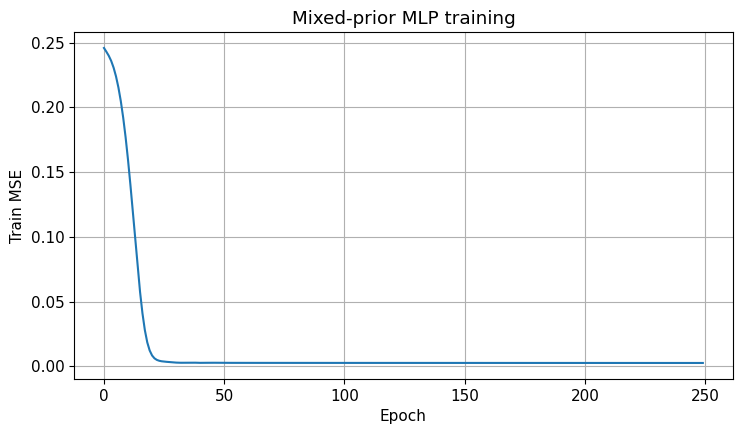

In [10]:
# ============================================================
# 10. Linear AI prior + optional MLP
# ============================================================

def fit_linear_ridge(X, Y, reg=1e-3):
    Xb = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
    I = np.eye(Xb.shape[1])
    return np.linalg.solve(Xb.T @ Xb + reg * I, Xb.T @ Y)

def predict_linear_ridge(X, W):
    Xb = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
    return Xb @ W

W_lin = fit_linear_ridge(X_train, Y_train, reg=1e-2)
Y_pred_lin = predict_linear_ridge(X_test, W_lin)
lin_rmse = float(np.sqrt(np.mean((Y_pred_lin - Y_test) ** 2)))
print("Linear mixed-prior compact RMSE:", lin_rmse)

mlp_result = None
if TORCH_AVAILABLE:
    torch.manual_seed(GLOBAL_SEED)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    class SmallMLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 256),
                nn.ReLU(),
                nn.Linear(256, 256),
                nn.ReLU(),
                nn.Linear(256, out_dim),
                nn.Sigmoid(),
            )
        def forward(self, x):
            return self.net(x)

    Xtr = torch.tensor(X_train, dtype=torch.float32, device=device)
    Ytr = torch.tensor(Y_train, dtype=torch.float32, device=device)
    Xte = torch.tensor(X_test, dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_test, dtype=torch.float32, device=device)

    model = SmallMLP(X_train.shape[1], Y_train.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    hist = []
    for epoch in range(250):
        opt.zero_grad()
        pred = model(Xtr)
        loss = F.mse_loss(pred, Ytr)
        loss.backward()
        opt.step()
        hist.append(float(loss.item()))

    with torch.no_grad():
        pred_test = model(Xte)
        test_rmse = float(torch.sqrt(torch.mean((pred_test - Yte) ** 2)).item())

    mlp_result = {"model": model, "device": device, "test_rmse": test_rmse, "history": hist}
    print("MLP mixed-prior compact RMSE:", test_rmse)

    fig, ax = plt.subplots()
    ax.plot(hist)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train MSE")
    ax.set_title("Mixed-prior MLP training")
    plt.show()
else:
    print("Torch not available; linear prior only.")


## Hybrid AI + GS for the mixed pair

We use the AI estimate as a soft spectral prior during the GS loop.


In [11]:
# ============================================================
# 11. Hybrid AI + GS
# ============================================================

def ai_prior_from_measurements(I_ref, I_lens, use_mlp=False):
    feat = pack_mixed_features(I_ref, I_lens, feature_len=feature_len)[None, :]
    if use_mlp and TORCH_AVAILABLE and mlp_result is not None:
        model = mlp_result["model"]
        device = mlp_result["device"]
        with torch.no_grad():
            y = model(torch.tensor(feat, dtype=torch.float32, device=device)).cpu().numpy()[0]
    else:
        y = predict_linear_ridge(feat, W_lin)[0]
    y = np.clip(y, 0.0, None)
    return compact_to_full(y, len(f))

def gs_time_lens_hybrid(I_ref, I_lens, ai_prior_full, n_iter=160, alpha=0.30):
    mag_ref = np.sqrt(np.maximum(I_ref, 0.0))
    mag_lens = np.sqrt(np.maximum(I_lens, 0.0))

    E0_init = np.sqrt(np.maximum(ai_prior_full, 0.0)) * np.exp(1j * np.zeros_like(ai_prior_full))
    e_ref_init = ifftc(E0_init * np.exp(1j * 0.5 * phi2_ref * w**2))
    e_ref = mag_ref * np.exp(1j * np.angle(e_ref_init))

    prev = e_ref.copy()
    history = {"err_ref": [], "err_lens": [], "update": [], "prior_strength": []}

    for _ in range(n_iter):
        # ref -> lens measurement domain
        e_lens_pred = prop_ref_to_lens(e_ref)
        err_lens = np.sqrt(np.mean((np.abs(e_lens_pred) - mag_lens) ** 2))
        e_lens = mag_lens * np.exp(1j * np.angle(e_lens_pred))

        # lens -> ref
        e_ref_pred = prop_lens_to_ref(e_lens)

        # move to reference spectrum and softly blend with AI prior
        E_ref_pred = fftc(e_ref_pred)
        E0_pred = E_ref_pred * np.exp(-1j * 0.5 * phi2_ref * w**2)

        phase = np.angle(E0_pred)
        E0_ai = np.sqrt(np.maximum(ai_prior_full, 0.0)) * np.exp(1j * phase)
        E0_blend = (1 - alpha) * E0_pred + alpha * E0_ai

        e_ref_forward = ifftc(E0_blend * np.exp(1j * 0.5 * phi2_ref * w**2))
        err_ref = np.sqrt(np.mean((np.abs(e_ref_forward) - mag_ref) ** 2))
        e_ref = mag_ref * np.exp(1j * np.angle(e_ref_forward))

        upd = np.sqrt(np.mean(np.abs(e_ref - prev) ** 2))
        prev = e_ref.copy()

        history["err_ref"].append(err_ref)
        history["err_lens"].append(err_lens)
        history["update"].append(upd)
        history["prior_strength"].append(alpha)

    E_ref_final = fftc(e_ref)
    E0_final = E_ref_final * np.exp(-1j * 0.5 * phi2_ref * w**2)
    S_final = normalize_peak(np.abs(E0_final) ** 2)

    return e_ref, S_final, history


In [12]:
# ============================================================
# 12. Run hybrid reconstructions
# ============================================================

S_prior_lin = ai_prior_from_measurements(I_ref, I_lens, use_mlp=False)
e_hybrid_lin, S_hybrid_lin, hist_hybrid_lin = gs_time_lens_hybrid(I_ref, I_lens, S_prior_lin, n_iter=160, alpha=0.30)

metrics_hybrid_lin = {
    "rmse": rmse(normalize_peak(S_case), normalize_peak(S_hybrid_lin)),
    "corr": correlation_coefficient(normalize_peak(S_case), normalize_peak(S_hybrid_lin)),
}

if TORCH_AVAILABLE and mlp_result is not None:
    S_prior_mlp = ai_prior_from_measurements(I_ref, I_lens, use_mlp=True)
    e_hybrid_mlp, S_hybrid_mlp, hist_hybrid_mlp = gs_time_lens_hybrid(I_ref, I_lens, S_prior_mlp, n_iter=160, alpha=0.30)
    metrics_hybrid_mlp = {
        "rmse": rmse(normalize_peak(S_case), normalize_peak(S_hybrid_mlp)),
        "corr": correlation_coefficient(normalize_peak(S_case), normalize_peak(S_hybrid_mlp)),
    }
else:
    S_prior_mlp = None
    S_hybrid_mlp = None
    hist_hybrid_mlp = None
    metrics_hybrid_mlp = None

print("Dispersion-only:", metrics_disp)
print("Time-lens GS:", metrics_lens)
print("Hybrid linear:", metrics_hybrid_lin)
print("Hybrid mlp:", metrics_hybrid_mlp)


Dispersion-only: {'rmse': 0.9201119303924356, 'corr': 0.010742460881496866}
Time-lens GS: {'rmse': 0.849289589917221, 'corr': -0.02024644056555355}
Hybrid linear: {'rmse': 0.01775018960669813, 'corr': 0.9975219965926417}
Hybrid mlp: {'rmse': 0.03330323487219362, 'corr': 0.9891558190094515}


## Final comparison


C:\Users\mrjel\AppData\Local\Temp\ipykernel_37164\3389156594.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


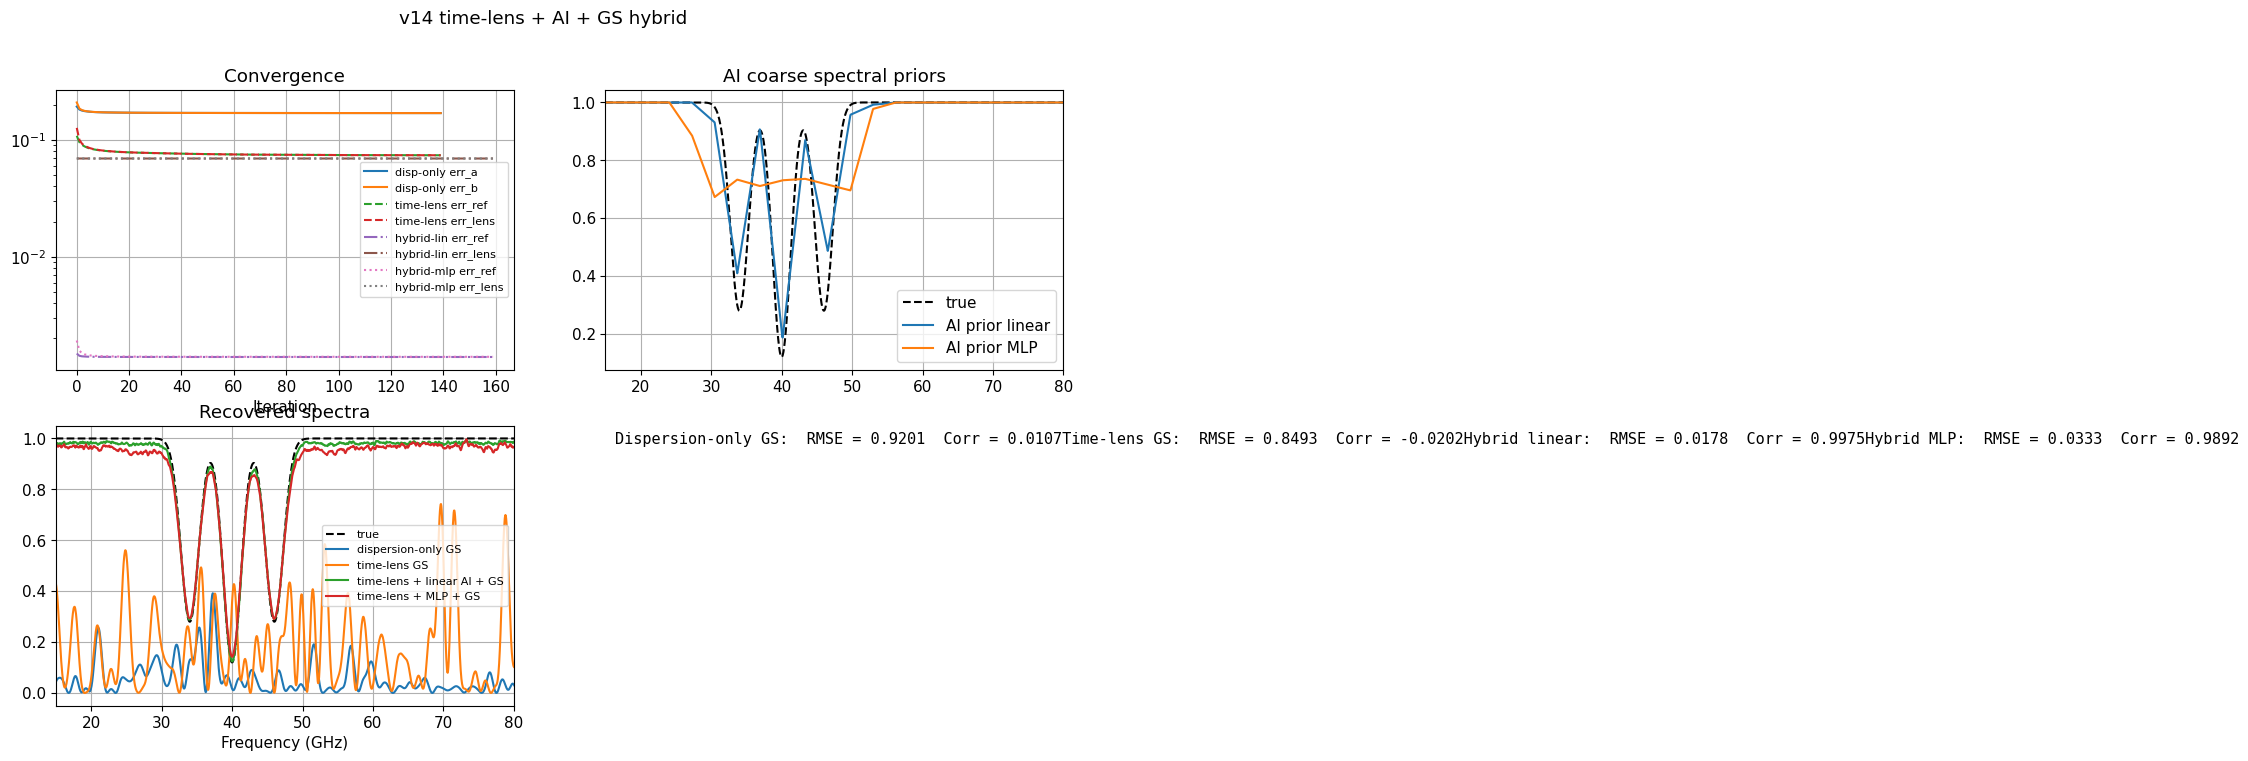

In [14]:
# ============================================================
# 13. Plots
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(13, 8))

# Convergence
axs[0, 0].plot(hist_disp["err_a"], label="disp-only err_a")
axs[0, 0].plot(hist_disp["err_b"], label="disp-only err_b")
axs[0, 0].plot(hist_lens["err_a"], "--", label="time-lens err_ref")
axs[0, 0].plot(hist_lens["err_b"], "--", label="time-lens err_lens")
axs[0, 0].plot(hist_hybrid_lin["err_ref"], "-.", label="hybrid-lin err_ref")
axs[0, 0].plot(hist_hybrid_lin["err_lens"], "-.", label="hybrid-lin err_lens")
if hist_hybrid_mlp is not None:
    axs[0, 0].plot(hist_hybrid_mlp["err_ref"], ":", label="hybrid-mlp err_ref")
    axs[0, 0].plot(hist_hybrid_mlp["err_lens"], ":", label="hybrid-mlp err_lens")
axs[0, 0].set_yscale("log")
axs[0, 0].set_title("Convergence")
axs[0, 0].set_xlabel("Iteration")
axs[0, 0].legend(fontsize=8)

# AI priors
axs[0, 1].plot(f / GHZ, normalize_peak(S_case), "k--", label="true")
axs[0, 1].plot(f / GHZ, normalize_peak(S_prior_lin), label="AI prior linear")
if S_prior_mlp is not None:
    axs[0, 1].plot(f / GHZ, normalize_peak(S_prior_mlp), label="AI prior MLP")
axs[0, 1].set_xlim(15, 80)
axs[0, 1].set_title("AI coarse spectral priors")
axs[0, 1].legend()

# Final recovered spectra
axs[1, 0].plot(f / GHZ, normalize_peak(S_case), "k--", label="true")
axs[1, 0].plot(f / GHZ, normalize_peak(S_rec_disp), label="dispersion-only GS")
axs[1, 0].plot(f / GHZ, normalize_peak(S_rec_lens), label="time-lens GS")
axs[1, 0].plot(f / GHZ, normalize_peak(S_hybrid_lin), label="time-lens + linear AI + GS")
if S_hybrid_mlp is not None:
    axs[1, 0].plot(f / GHZ, normalize_peak(S_hybrid_mlp), label="time-lens + MLP + GS")
axs[1, 0].set_xlim(15, 80)
axs[1, 0].set_title("Recovered spectra")
axs[1, 0].set_xlabel("Frequency (GHz)")
axs[1, 0].legend(fontsize=8)

# Metrics text
axs[1, 1].axis("off")
lines = [
    "Dispersion-only GS:",
    f"  RMSE = {metrics_disp['rmse']:.4f}",
    f"  Corr = {metrics_disp['corr']:.4f}",
    "",
    "Time-lens GS:",
    f"  RMSE = {metrics_lens['rmse']:.4f}",
    f"  Corr = {metrics_lens['corr']:.4f}",
    "",
    "Hybrid linear:",
    f"  RMSE = {metrics_hybrid_lin['rmse']:.4f}",
    f"  Corr = {metrics_hybrid_lin['corr']:.4f}",
]
if metrics_hybrid_mlp is not None:
    lines += [
        "",
        "Hybrid MLP:",
        f"  RMSE = {metrics_hybrid_mlp['rmse']:.4f}",
        f"  Corr = {metrics_hybrid_mlp['corr']:.4f}",
    ]
axs[1, 1].text(0.02, 0.98, "".join(lines), va="top", family="monospace", fontsize=11)

fig.suptitle("v14 time-lens + AI + GS hybrid")
plt.tight_layout()
plt.show()


## Physical interpretation

This notebook is the first version where the richer measurement physics and the inverse method are improved together.

### Dispersion-only GS
Physics is simple, but measurements are less informative.

### Time-lens GS
Measurement diversity improves, but GS alone still struggles.

### Time-lens + AI + GS
The AI prior gives the inverse solver a physically plausible starting structure, and GS refines it using the mixed measurement constraints.

That is why this is the most practical version so far.


In [ ]:
# ============================================================
# 14. Save summary
# ============================================================

summary = {
    "torch_available": TORCH_AVAILABLE,
    "linear_prior_rmse_compact": lin_rmse,
    "metrics_dispersion_only": metrics_disp,
    "metrics_time_lens_gs": metrics_lens,
    "metrics_hybrid_linear": metrics_hybrid_lin,
    "metrics_hybrid_mlp": metrics_hybrid_mlp,
    "mixed_measurement_params": {
        "phi2_ref": phi2_ref,
        "phi2_pre": phi2_pre,
        "C_lens": C_lens,
        "phi2_post": phi2_post,
    },
}

if mlp_result is not None:
    summary["mlp_prior_rmse_compact"] = mlp_result["test_rmse"]

out_dir = Path("/mnt/data/phase_recovery_v14_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / "phase_recovery_v14_summary.json"
with summary_path.open("w", encoding="utf-8") as fjson:
    json.dump(summary, fjson, indent=2)

print("Saved summary to:", summary_path)


## Suggested commit message

```text
feat: add v14 time-lens + AI + GS hybrid notebook

- keep dispersion-only and time-lens GS baselines for comparison
- build mixed-measurement dataset from one dispersed plane and one time-lens plane
- train compact linear and optional MLP spectral priors
- add hybrid GS refinement using AI prior with mixed time-lens constraints
- compare all methods on a shared three-dip benchmark
- save summary metrics for reproducibility
```
